In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import confusion_matrix
import plotly.express as px


In [ ]:
df = pd.read_csv("data/egx/ABUK.csv")

df.head()

,date,open,high,low,close,volume
0,2015-01-04,10.666666,10.666666,10.666666,10.666666,0
1,2015-01-05,10.666666,10.800000,10.373333,10.794666,295290
2,2015-01-06,10.794666,10.800000,10.800000,10.800000,765000
3,2015-01-08,10.800000,10.400666,10.400666,10.800000,255
4,2015-01-11,10.800000,10.800000,10.800000,10.800000,0


In [ ]:
close = df["close"].values.astype("float32")

window = 5

X = []
y = []

for i in range(window, len(close) - 1):

    # Last 5 closing prices
    X.append(close[i-window:i])

    # Tomorrow's direction
    y.append(float(close[i+1] > close[i]))

X = np.array(X, dtype="float32")
y = np.array(y, dtype="float32")

In [ ]:
# today_close = df["close"].values[:-1].astype("float32")
# tomorrow_close = df["close"].values[1:].astype("float32")

# # 1 = UP
# # 0 = DOWN
# y = (tomorrow_close > today_close).astype("float32")

# X = today_close.reshape(-1, 1)

In [71]:
split = int(len(X) * 0.7)

Xtr = torch.tensor(X[:split])
ytr = torch.tensor(y[:split])

Xte = torch.tensor(X[split:])
yte = torch.tensor(y[split:])

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
# class MLP(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(1, 32),
#             nn.ReLU(),
#             nn.Linear(32, 1)
#         )

#     def forward(self, x):
#         return self.net(x).squeeze(-1)

In [80]:
torch.manual_seed(0)

model = MLP()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = nn.BCEWithLogitsLoss()

train_hist = []
test_hist = []

In [81]:
for epoch in range(400):

    model.train()

    optimizer.zero_grad()

    train_logits = model(Xtr)

    train_loss = criterion(train_logits, ytr)

    train_loss.backward()

    optimizer.step()

    train_hist.append(train_loss.item())

    model.eval()

    with torch.no_grad():
        test_logits = model(Xte)
        test_loss = criterion(test_logits, yte)

    test_hist.append(test_loss.item())

In [83]:
print(f"Final train loss: {train_hist[-1]:.4f}")
print(f"Final test loss:  {test_hist[-1]:.4f}")

Final train loss: 0.6668
Final test loss:  0.7723


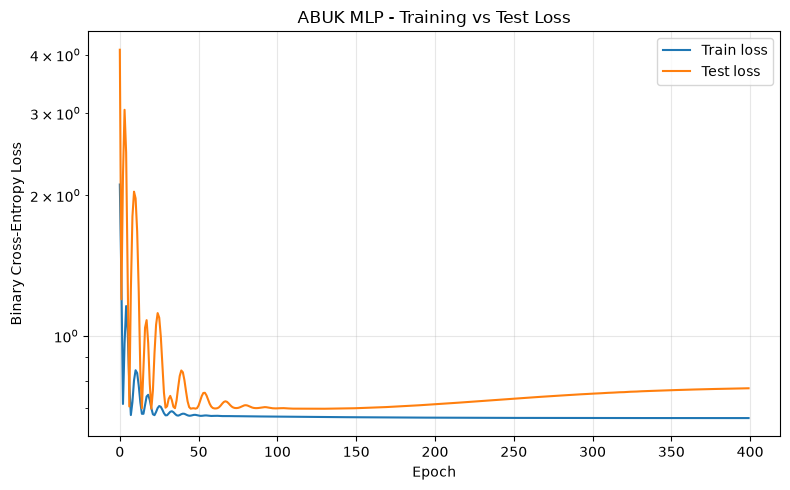

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(train_hist, label="Train loss")
plt.plot(test_hist, label="Test loss")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title("ABUK MLP - Training vs Test Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [85]:
loss_df = pd.DataFrame({
    "Epoch": range(1, len(train_hist) + 1),
    "Train Loss": train_hist,
    "Test Loss": test_hist
})

fig = px.line(
    loss_df,
    x="Epoch",
    y=["Train Loss", "Test Loss"],
    title="ABUK MLP - Training vs Test BCE Loss",
    labels={
        "value": "Binary Cross-Entropy Loss",
        "variable": "Loss Type"
    }
)

fig.show()

In [86]:
model.eval()

with torch.no_grad():
    test_logits = model(Xte)
    test_probabilities = torch.sigmoid(test_logits)

# Convert probabilities to UP/DOWN
predicted_direction = (test_probabilities >= 0.5).int().numpy()

# Actual values
actual_direction = yte.numpy().astype(int)

# Create a table
results = pd.DataFrame({
    "Actual": np.where(actual_direction == 1, "UP", "DOWN"),
    "Predicted": np.where(predicted_direction == 1, "UP", "DOWN"),
    "Probability_UP": test_probabilities.numpy()
})

results.head(20)

,Actual,Predicted,Probability_UP
0,UP,UP,0.539565
1,UP,UP,0.511515
2,DOWN,UP,0.566127
3,DOWN,UP,0.538928
4,UP,UP,0.541831
5,DOWN,UP,0.557762
6,DOWN,UP,0.537732
7,DOWN,UP,0.531612
8,UP,UP,0.541712
9,UP,UP,0.534626


In [87]:
print("Actual direction:")
print(np.unique(actual_direction, return_counts=True))

print("\nPredicted direction:")
print(np.unique(predicted_direction, return_counts=True))

Actual direction:
(array([0, 1]), array([474, 382]))

Predicted direction:
(array([0, 1], dtype=int32), array([ 13, 843]))


In [88]:
# Confusion matrix
cm = confusion_matrix(
    actual_direction,
    predicted_direction,
    labels=[0, 1]
)

# Row-wise percentages
# This tells us the percentage of each actual class
cm_percentage = cm / cm.sum(axis=1, keepdims=True) * 100

# Text displayed inside each cell
text = np.empty(cm.shape, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text[i, j] = (
            f"{cm[i, j]}<br>"
            f"({cm_percentage[i, j]:.2f}%)"
        )

# DataFrame
cm_df = pd.DataFrame(
    cm,
    index=["DOWN", "UP"],
    columns=["DOWN", "UP"]
)

# Heatmap
fig = px.imshow(
    cm_df,
    x=["DOWN", "UP"],
    y=["DOWN", "UP"],
    labels={
        "x": "Predicted Direction",
        "y": "Actual Direction",
        "color": "Number of Samples"
    },
    title="ABUK MLP - UP/DOWN Classification Confusion Matrix",
    text_auto=False,
    aspect="auto"
)

# Count + percentage inside cells
fig.update_traces(
    text=text,
    texttemplate="%{text}",
    hovertemplate=(
        "Actual: %{y}<br>"
        "Predicted: %{x}<br>"
        "Count: %{z}<br>"
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Predicted Direction",
    yaxis_title="Actual Direction",
    width=700,
    height=600
)

fig.show()

In [90]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    actual_direction,
    predicted_direction
)

precision = precision_score(
    actual_direction,
    predicted_direction
)

recall = recall_score(
    actual_direction,
    predicted_direction
)

f1 = f1_score(
    actual_direction,
    predicted_direction
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.4451
Precision: 0.4448
Recall   : 0.9817
F1-score : 0.6122
